# Padronizacao dos graficos - Counting Sort

Este notebook usa os CSVs gerados pelos benchmarks em Python e Rust para atender ao item 2.3 da especificacao do projeto:

- eixo X: tamanho da entrada (`n`);
- eixo Y: tempo de execucao em segundos;
- sobreposicao da curva teorica esperada;
- uso de escala logaritmica quando ajuda a visualizar diferencas grandes entre linguagens e tamanhos.

Para Counting Sort, a complexidade teorica usada e `T(n, k) = n + k`. Nos experimentos atuais, `k = n`, entao a curva teorica cresce linearmente em relacao a `n`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


def localizar_raiz_projeto():
    current_dir = Path.cwd().resolve()
    for candidate in [current_dir, *current_dir.parents]:
        if (candidate / "rust" / "Cargo.toml").exists() and (candidate / "python").exists():
            return candidate
    raise FileNotFoundError("Nao foi possivel localizar a raiz do projeto.")


project_root = localizar_raiz_projeto()
analysis_dir = project_root / "analise"
data_dir = analysis_dir / "dados"
tables_dir = analysis_dir / "tabelas"
plots_dir = analysis_dir / "graficos"

tables_dir.mkdir(exist_ok=True)
plots_dir.mkdir(exist_ok=True)

python_csv = data_dir / "resultados_python.csv"
rust_csv = data_dir / "resultados_rust.csv"

print(f"Raiz do projeto: {project_root}")
print(f"Lendo: {python_csv}")
print(f"Lendo: {rust_csv}")

Raiz do projeto: C:\Users\gusta\OneDrive\Documentos\Equipe7_TCB
Lendo: C:\Users\gusta\OneDrive\Documentos\Equipe7_TCB\analise\dados\resultados_python.csv
Lendo: C:\Users\gusta\OneDrive\Documentos\Equipe7_TCB\analise\dados\resultados_rust.csv


In [2]:
df_python = pd.read_csv(python_csv)
df_rust = pd.read_csv(rust_csv)

df = pd.concat([df_python, df_rust], ignore_index=True)
df["ordenado"] = df["ordenado"].astype(str).str.lower().map({"true": True, "false": False})
df["complexidade_teorica"] = df["n"] + df["k"]

ordem_casos = ["melhor", "medio", "pior"]
ordem_tamanhos = ["pequena", "media", "grande"]
df["caso"] = pd.Categorical(df["caso"], categories=ordem_casos, ordered=True)
df["tamanho_label"] = pd.Categorical(df["tamanho_label"], categories=ordem_tamanhos, ordered=True)

print(f"Total de medicoes: {len(df)}")
print(f"Todas as execucoes ordenaram corretamente? {df['ordenado'].all()}")
df.head()

Total de medicoes: 540
Todas as execucoes ordenaram corretamente? True


,linguagem,caso,tamanho_label,n,k,execucao,tempo_segundos,ordenado,complexidade_teorica
0,python,melhor,pequena,1000,1000,1,0.000329,True,2000
1,python,melhor,pequena,1000,1000,2,0.000315,True,2000
2,python,melhor,pequena,1000,1000,3,0.000286,True,2000
3,python,melhor,pequena,1000,1000,4,0.000295,True,2000
4,python,melhor,pequena,1000,1000,5,0.000277,True,2000


In [3]:
resumo = (
    df.groupby(["linguagem", "caso", "tamanho_label", "n", "k"], observed=True)
    .agg(
        media_segundos=("tempo_segundos", "mean"),
        desvio_padrao=("tempo_segundos", "std"),
        minimo=("tempo_segundos", "min"),
        maximo=("tempo_segundos", "max"),
        execucoes=("tempo_segundos", "count"),
        complexidade_teorica=("complexidade_teorica", "first"),
    )
    .reset_index()
)
resumo["velocidade_elementos_por_segundo"] = resumo["n"] / resumo["media_segundos"]

resumo.to_csv(tables_dir / "resumo_tempos.csv", index=False)
resumo

,linguagem,caso,tamanho_label,n,k,media_segundos,desvio_padrao,minimo,maximo,execucoes,complexidade_teorica,velocidade_elementos_por_segundo
0,python,melhor,pequena,1000,1000,0.000251,5.014167e-05,0.000150,0.000329,30,2000,3.991219e+06
1,python,melhor,media,10000,10000,0.001848,3.895947e-04,0.001462,0.002597,30,20000,5.410475e+06
2,python,melhor,grande,1000000,1000000,0.185860,1.848214e-02,0.161732,0.222089,30,2000000,5.380383e+06
3,python,medio,pequena,1000,1000,0.000255,3.932539e-05,0.000162,0.000297,30,2000,3.919007e+06
4,python,medio,media,10000,10000,0.001778,3.527933e-04,0.001526,0.002803,30,20000,5.624234e+06
5,python,medio,grande,1000000,1000000,0.194538,1.112578e-02,0.185610,0.228988,30,2000000,5.140397e+06
6,python,pior,pequena,1000,1000,0.000189,5.550643e-05,0.000146,0.000344,30,2000,5.291752e+06
7,python,pior,media,10000,10000,0.001738,3.207029e-04,0.001482,0.002652,30,20000,5.752581e+06
8,python,pior,grande,1000000,1000000,0.161044,1.941814e-03,0.158407,0.166695,30,2000000,6.209498e+06
9,rust,melhor,pequena,1000,1000,0.000002,1.145827e-06,0.000002,0.000008,30,2000,4.076087e+08


## Ajuste da curva teorica

A curva teorica do Counting Sort e proporcional a `n + k`. Como a curva teorica nao esta em segundos por si so, ajustamos uma constante `c` para cada combinacao de linguagem e caso:

`tempo_teorico_ajustado = c * (n + k)`

Esse ajuste permite sobrepor a forma teorica aos tempos reais e verificar se o crescimento observado acompanha a tendencia linear esperada.

In [4]:
resumo_ajustado = resumo.copy()
resumo_ajustado["constante_c"] = np.nan
resumo_ajustado["tempo_teorico_ajustado"] = np.nan

for (linguagem, caso), indices in resumo_ajustado.groupby(["linguagem", "caso"], observed=True).groups.items():
    grupo = resumo_ajustado.loc[indices]
    x = grupo["complexidade_teorica"].to_numpy(dtype=float)
    y = grupo["media_segundos"].to_numpy(dtype=float)
    c = (x @ y) / (x @ x)
    resumo_ajustado.loc[indices, "constante_c"] = c
    resumo_ajustado.loc[indices, "tempo_teorico_ajustado"] = c * grupo["complexidade_teorica"]

resumo_ajustado.to_csv(tables_dir / "resumo_tempos_com_teoria.csv", index=False)
resumo_ajustado.head(9)

,linguagem,caso,tamanho_label,n,k,media_segundos,desvio_padrao,minimo,maximo,execucoes,complexidade_teorica,velocidade_elementos_por_segundo,constante_c,tempo_teorico_ajustado
0,python,melhor,pequena,1000,1000,0.000251,0.000050,0.000150,0.000329,30,2000,3.991219e+06,9.293016e-08,0.000186
1,python,melhor,media,10000,10000,0.001848,0.000390,0.001462,0.002597,30,20000,5.410475e+06,9.293016e-08,0.001859
2,python,melhor,grande,1000000,1000000,0.185860,0.018482,0.161732,0.222089,30,2000000,5.380383e+06,9.293016e-08,0.185860
3,python,medio,pequena,1000,1000,0.000255,0.000039,0.000162,0.000297,30,2000,3.919007e+06,9.726795e-08,0.000195
4,python,medio,media,10000,10000,0.001778,0.000353,0.001526,0.002803,30,20000,5.624234e+06,9.726795e-08,0.001945
5,python,medio,grande,1000000,1000000,0.194538,0.011126,0.185610,0.228988,30,2000000,5.140397e+06,9.726795e-08,0.194536
6,python,pior,pequena,1000,1000,0.000189,0.000056,0.000146,0.000344,30,2000,5.291752e+06,8.052246e-08,0.000161
7,python,pior,media,10000,10000,0.001738,0.000321,0.001482,0.002652,30,20000,5.752581e+06,8.052246e-08,0.001610
8,python,pior,grande,1000000,1000000,0.161044,0.001942,0.158407,0.166695,30,2000000,6.209498e+06,8.052246e-08,0.161045


## Grafico 1 - Tempos reais por linguagem e caso

Este grafico mostra `n` no eixo X e o tempo medio no eixo Y. As barras verticais indicam o desvio-padrao das 30 execucoes. A escala logaritmica ajuda porque Rust e Python ficam em faixas de tempo bem diferentes.

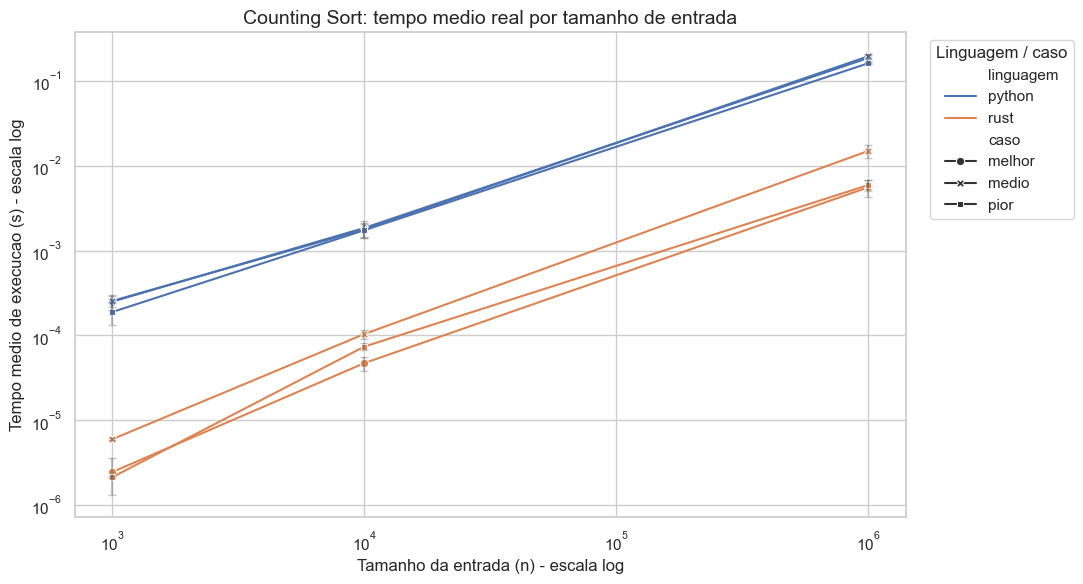

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.lineplot(
    data=resumo_ajustado,
    x="n",
    y="media_segundos",
    hue="linguagem",
    style="caso",
    markers=True,
    dashes=False,
    ax=ax,
)

for _, row in resumo_ajustado.iterrows():
    ax.errorbar(
        row["n"],
        row["media_segundos"],
        yerr=row["desvio_padrao"],
        fmt="none",
        color="0.35",
        alpha=0.35,
        capsize=3,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Counting Sort: tempo medio real por tamanho de entrada")
ax.set_xlabel("Tamanho da entrada (n) - escala log")
ax.set_ylabel("Tempo medio de execucao (s) - escala log")
ax.legend(title="Linguagem / caso", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(plots_dir / "01_tempos_reais_log.png", dpi=200, bbox_inches="tight")
plt.show()

## Grafico 2 - Sobreposicao teorica

Cada painel compara os tempos reais com a curva teorica ajustada `c*(n+k)`. Como `k = n` nos testes atuais, a curva esperada e linear em relacao ao tamanho da entrada.

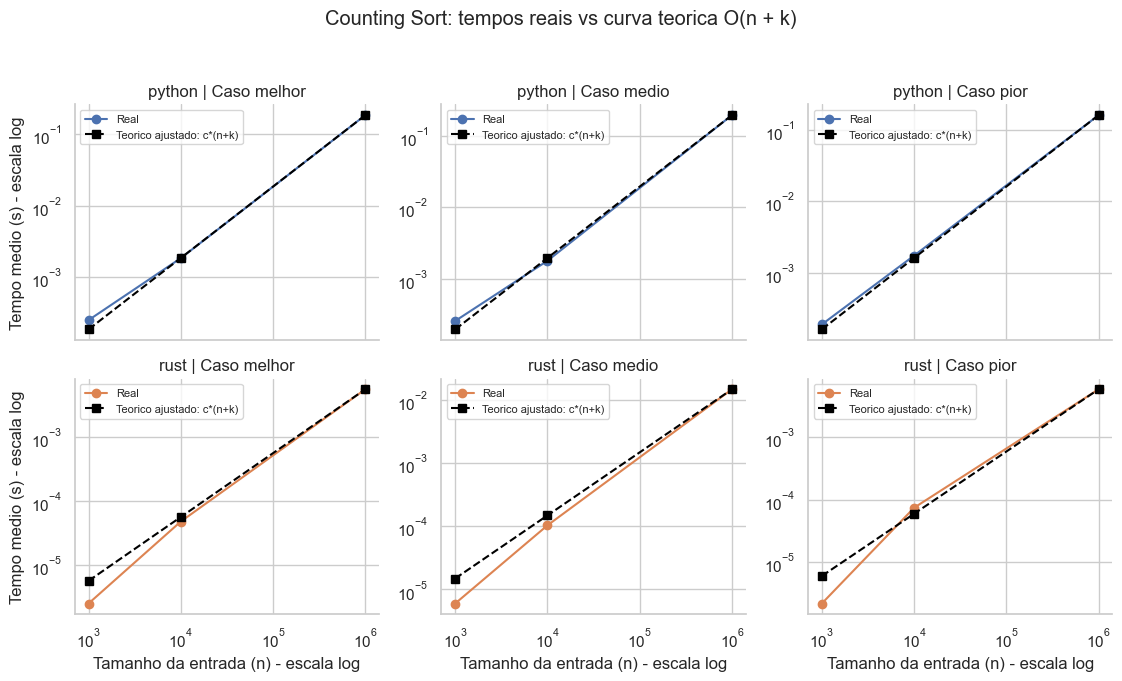

In [6]:
g = sns.FacetGrid(
    resumo_ajustado,
    row="linguagem",
    col="caso",
    hue="linguagem",
    sharey=False,
    height=3.3,
    aspect=1.15,
)

def plot_real_vs_teorico(data, color, **kwargs):
    data = data.sort_values("n")
    plt.plot(data["n"], data["media_segundos"], marker="o", color=color, label="Real")
    plt.plot(
        data["n"],
        data["tempo_teorico_ajustado"],
        marker="s",
        linestyle="--",
        color="black",
        label="Teorico ajustado: c*(n+k)",
    )
    plt.xscale("log")
    plt.yscale("log")

g.map_dataframe(plot_real_vs_teorico)
g.set_axis_labels("Tamanho da entrada (n) - escala log", "Tempo medio (s) - escala log")
g.set_titles(row_template="{row_name}", col_template="Caso {col_name}")

for ax in g.axes.flat:
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles[:2], labels[:2], loc="best", fontsize=8)

g.fig.suptitle("Counting Sort: tempos reais vs curva teorica O(n + k)", y=1.03)
g.fig.tight_layout()
g.fig.savefig(plots_dir / "02_real_vs_teorico_log.png", dpi=200, bbox_inches="tight")
plt.show()

## Grafico 3 - Comparacao direta entre Python e Rust

Este grafico usa os tempos medios agregados e compara as duas linguagens no mesmo painel para cada caso. A escala logaritmica no eixo Y facilita a leitura quando uma linguagem e muito mais rapida que a outra.

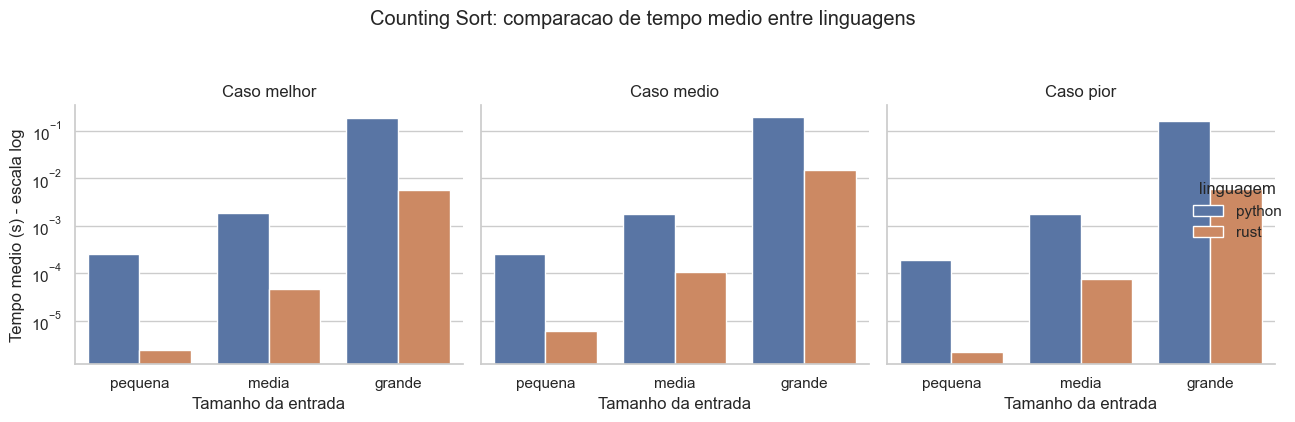

In [7]:
g = sns.catplot(
    data=resumo_ajustado,
    kind="bar",
    x="tamanho_label",
    y="media_segundos",
    hue="linguagem",
    col="caso",
    order=ordem_tamanhos,
    col_order=ordem_casos,
    height=4,
    aspect=1,
    errorbar=None,
)

for ax in g.axes.flat:
    ax.set_yscale("log")
    ax.set_xlabel("Tamanho da entrada")
    ax.set_ylabel("Tempo medio (s) - escala log")

g.set_titles("Caso {col_name}")
g.fig.suptitle("Counting Sort: comparacao de tempo medio entre linguagens", y=1.05)
g.fig.tight_layout()
g.fig.savefig(plots_dir / "03_comparacao_linguagens_barras_log.png", dpi=200, bbox_inches="tight")
plt.show()

## Grafico 4 - Velocidade de processamento

Este grafico compara diretamente a velocidade das linguagens em elementos processados por segundo. Diferente do speedup, aqui as duas linguagens aparecem com seus valores absolutos de throughput.

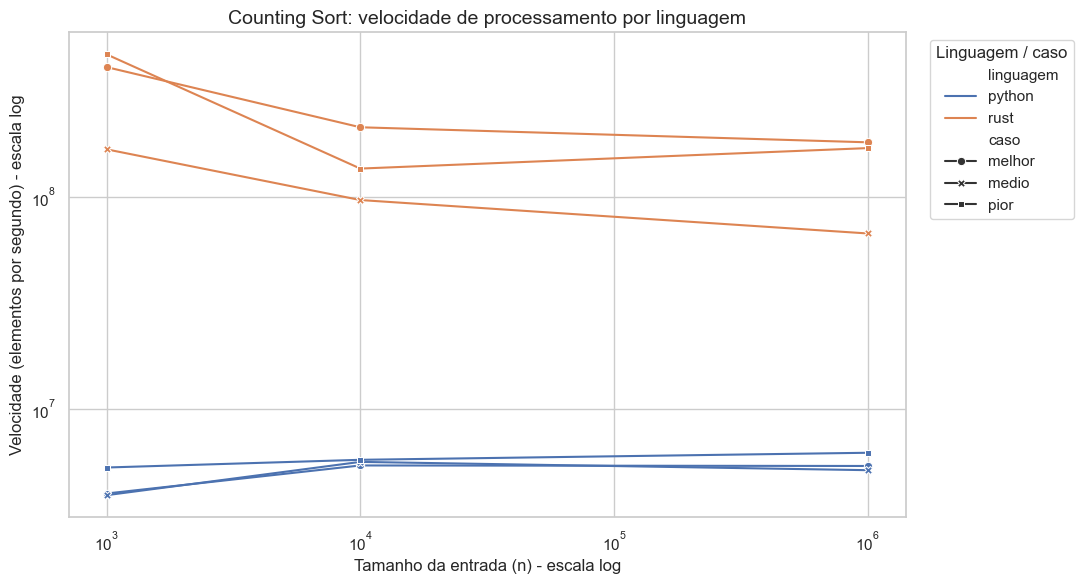

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.lineplot(
    data=resumo_ajustado,
    x="n",
    y="velocidade_elementos_por_segundo",
    hue="linguagem",
    style="caso",
    markers=True,
    dashes=False,
    ax=ax,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Counting Sort: velocidade de processamento por linguagem")
ax.set_xlabel("Tamanho da entrada (n) - escala log")
ax.set_ylabel("Velocidade (elementos por segundo) - escala log")
ax.legend(title="Linguagem / caso", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(plots_dir / "04_velocidade_linguagens_log.png", dpi=200, bbox_inches="tight")
plt.show()

## Grafico 5 - Speedup Rust vs Python

O speedup e calculado como `tempo_python / tempo_rust`. Valores maiores que 1 indicam quantas vezes Rust foi mais rapido que Python em cada combinacao de tamanho e caso.

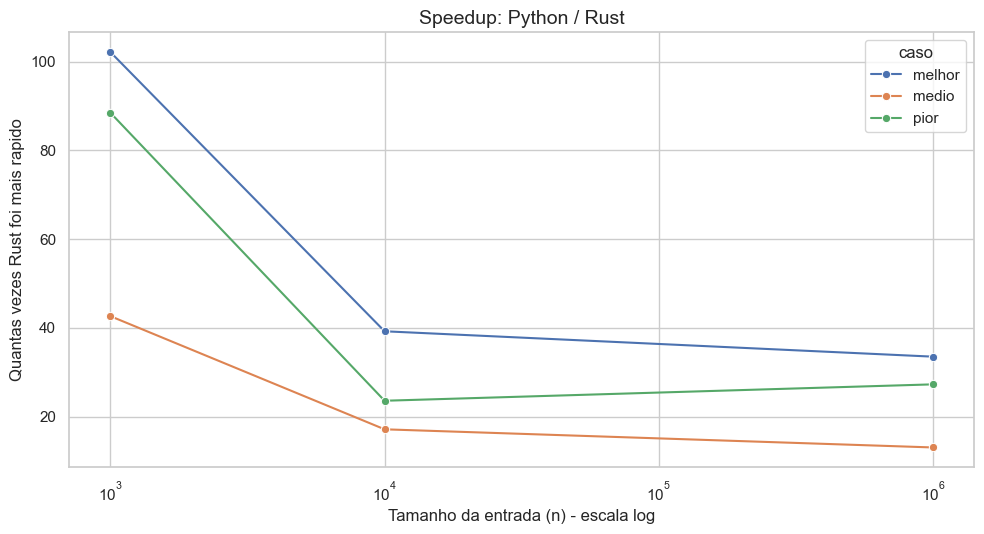

linguagem,caso,tamanho_label,n,python,rust,speedup_rust_vs_python
0,melhor,pequena,1000,0.000251,0.000002,102.126359
1,melhor,media,10000,0.001848,0.000047,39.221900
2,melhor,grande,1000000,0.185860,0.005547,33.503627
3,medio,pequena,1000,0.000255,0.000006,42.622494
4,medio,media,10000,0.001778,0.000104,17.132588
5,medio,grande,1000000,0.194538,0.014914,13.043985
6,pior,pequena,1000,0.000189,0.000002,88.443058
7,pior,media,10000,0.001738,0.000074,23.566587
8,pior,grande,1000000,0.161044,0.005907,27.261783


In [9]:
pivot = resumo.pivot_table(
    index=["caso", "tamanho_label", "n"],
    columns="linguagem",
    values="media_segundos",
    observed=True,
).reset_index()

pivot["speedup_rust_vs_python"] = pivot["python"] / pivot["rust"]
pivot.to_csv(tables_dir / "speedup_rust_vs_python.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(
    data=pivot,
    x="n",
    y="speedup_rust_vs_python",
    hue="caso",
    marker="o",
    ax=ax,
)
ax.set_xscale("log")
ax.set_title("Speedup: Python / Rust")
ax.set_xlabel("Tamanho da entrada (n) - escala log")
ax.set_ylabel("Quantas vezes Rust foi mais rapido")
fig.tight_layout()
fig.savefig(plots_dir / "05_speedup_rust_vs_python.png", dpi=200, bbox_inches="tight")
plt.show()

pivot

## Experimento complementar - Variacao de k

Esta secao nao substitui os cenarios exigidos de melhor, medio e pior caso. Ela e um experimento complementar para mostrar uma caracteristica especifica do Counting Sort: o custo tambem depende do intervalo de valores `k`.

Aqui mantemos `n = 100.000` e variamos `k` em tres situacoes:

- `k_pequeno`: `k = 100`;
- `k_igual_n`: `k = 100.000`;
- `k_grande`: `k = 1.000.000`.

In [10]:
python_k_csv = data_dir / "resultados_python_variacao_k.csv"
rust_k_csv = data_dir / "resultados_rust_variacao_k.csv"

df_k_python = pd.read_csv(python_k_csv)
df_k_rust = pd.read_csv(rust_k_csv)
df_k = pd.concat([df_k_python, df_k_rust], ignore_index=True)
df_k["ordenado"] = df_k["ordenado"].astype(str).str.lower().map({"true": True, "false": False})
df_k["complexidade_teorica"] = df_k["n"] + df_k["k"]

ordem_k = ["k_pequeno", "k_igual_n", "k_grande"]
df_k["cenario_k"] = pd.Categorical(df_k["cenario_k"], categories=ordem_k, ordered=True)

print(f"Total de medicoes na variacao de k: {len(df_k)}")
print(f"Todas as execucoes ordenaram corretamente? {df_k['ordenado'].all()}")
df_k.head()

Total de medicoes na variacao de k: 180
Todas as execucoes ordenaram corretamente? True


,linguagem,cenario_k,n,k,execucao,tempo_segundos,ordenado,complexidade_teorica
0,python,k_pequeno,100000,100,1,0.005357,True,100100
1,python,k_pequeno,100000,100,2,0.005772,True,100100
2,python,k_pequeno,100000,100,3,0.007426,True,100100
3,python,k_pequeno,100000,100,4,0.006478,True,100100
4,python,k_pequeno,100000,100,5,0.006466,True,100100


In [11]:
resumo_k = (
    df_k.groupby(["linguagem", "cenario_k", "n", "k"], observed=True)
    .agg(
        media_segundos=("tempo_segundos", "mean"),
        desvio_padrao=("tempo_segundos", "std"),
        minimo=("tempo_segundos", "min"),
        maximo=("tempo_segundos", "max"),
        execucoes=("tempo_segundos", "count"),
        complexidade_teorica=("complexidade_teorica", "first"),
    )
    .reset_index()
)
resumo_k["velocidade_elementos_por_segundo"] = resumo_k["n"] / resumo_k["media_segundos"]

resumo_k_ajustado = resumo_k.copy()
resumo_k_ajustado["constante_c"] = np.nan
resumo_k_ajustado["tempo_teorico_ajustado"] = np.nan

for linguagem, indices in resumo_k_ajustado.groupby("linguagem", observed=True).groups.items():
    grupo = resumo_k_ajustado.loc[indices]
    x = grupo["complexidade_teorica"].to_numpy(dtype=float)
    y = grupo["media_segundos"].to_numpy(dtype=float)
    c = (x @ y) / (x @ x)
    resumo_k_ajustado.loc[indices, "constante_c"] = c
    resumo_k_ajustado.loc[indices, "tempo_teorico_ajustado"] = c * grupo["complexidade_teorica"]

resumo_k_ajustado.to_csv(tables_dir / "resumo_variacao_k.csv", index=False)
resumo_k_ajustado

,linguagem,cenario_k,n,k,media_segundos,desvio_padrao,minimo,maximo,execucoes,complexidade_teorica,velocidade_elementos_por_segundo,constante_c,tempo_teorico_ajustado
0,python,k_pequeno,100000,100,0.006406,0.001127,0.005164,0.009810,30,100100,1.561068e+07,1.057498e-07,0.010586
1,python,k_igual_n,100000,100000,0.020026,0.002860,0.016124,0.028157,30,200000,4.993439e+06,1.057498e-07,0.021150
2,python,k_grande,100000,1000000,0.116909,0.012195,0.104600,0.157313,30,1100000,8.553631e+05,1.057498e-07,0.116325
3,rust,k_pequeno,100000,100,0.000095,0.000011,0.000089,0.000137,30,100100,1.051156e+09,4.911637e-09,0.000492
4,rust,k_igual_n,100000,100000,0.000624,0.000060,0.000583,0.000793,30,200000,1.601469e+08,4.911637e-09,0.000982
5,rust,k_grande,100000,1000000,0.005504,0.000970,0.004170,0.007556,30,1100000,1.816875e+07,4.911637e-09,0.005403


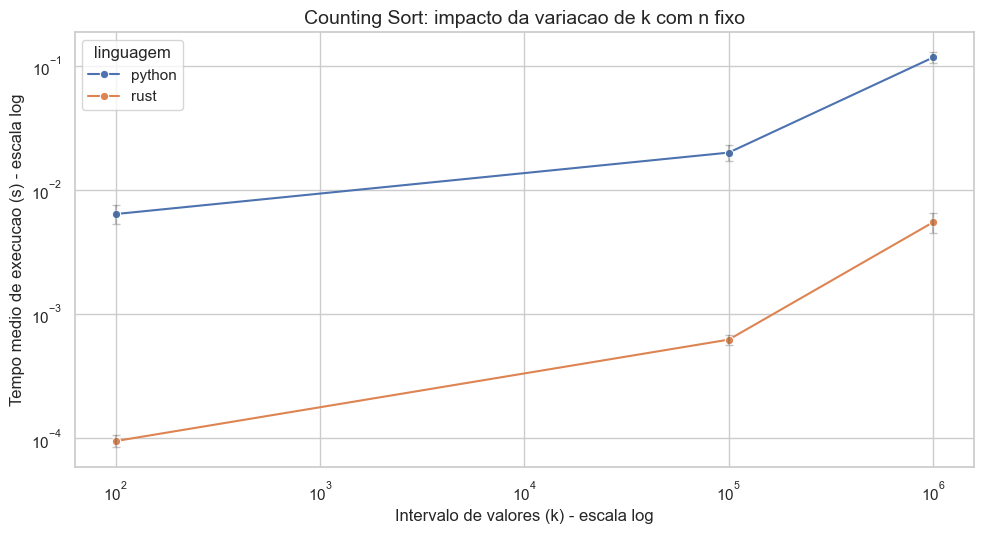

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.5))

sns.lineplot(
    data=resumo_k_ajustado.sort_values("k"),
    x="k",
    y="media_segundos",
    hue="linguagem",
    marker="o",
    ax=ax,
)

for _, row in resumo_k_ajustado.iterrows():
    ax.errorbar(
        row["k"],
        row["media_segundos"],
        yerr=row["desvio_padrao"],
        fmt="none",
        color="0.35",
        alpha=0.35,
        capsize=3,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Counting Sort: impacto da variacao de k com n fixo")
ax.set_xlabel("Intervalo de valores (k) - escala log")
ax.set_ylabel("Tempo medio de execucao (s) - escala log")
fig.tight_layout()
fig.savefig(plots_dir / "06_variacao_k_tempos_log.png", dpi=200, bbox_inches="tight")
plt.show()

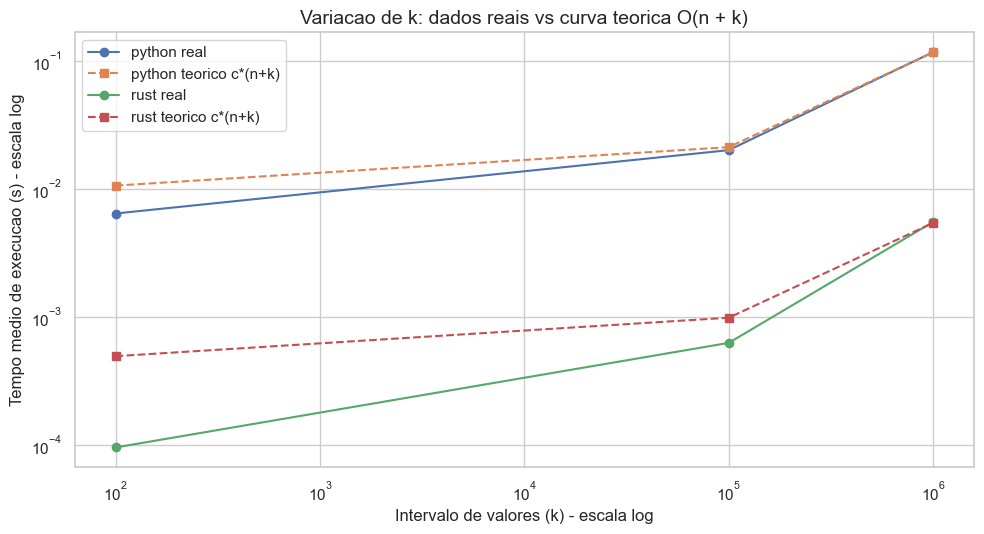

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for linguagem, grupo in resumo_k_ajustado.groupby("linguagem", observed=True):
    grupo = grupo.sort_values("k")
    ax.plot(grupo["k"], grupo["media_segundos"], marker="o", label=f"{linguagem} real")
    ax.plot(
        grupo["k"],
        grupo["tempo_teorico_ajustado"],
        marker="s",
        linestyle="--",
        label=f"{linguagem} teorico c*(n+k)",
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Variacao de k: dados reais vs curva teorica O(n + k)")
ax.set_xlabel("Intervalo de valores (k) - escala log")
ax.set_ylabel("Tempo medio de execucao (s) - escala log")
ax.legend()
fig.tight_layout()
fig.savefig(plots_dir / "07_variacao_k_real_vs_teorico_log.png", dpi=200, bbox_inches="tight")
plt.show()

## Arquivos gerados

O notebook salva automaticamente:

- `analise/tabelas/resumo_tempos.csv`: media, desvio-padrao, minimo e maximo por linguagem/caso/tamanho;
- `analise/tabelas/resumo_tempos_com_teoria.csv`: resumo com a curva teorica ajustada;
- `analise/tabelas/speedup_rust_vs_python.csv`: comparacao de velocidade relativa entre Python e Rust;
- `analise/tabelas/resumo_variacao_k.csv`: resumo do experimento complementar variando `k`;
- imagens `.png` em `analise/graficos/`, prontas para usar no relatorio ou nos slides.